<a href="https://colab.research.google.com/github/RameeshaK/heartDiseaseml/blob/main/HeartDiseaseMLProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/heart.csv"
df = pd.read_csv(url)


print("Dataset Loaded Successfully!")
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Loaded Successfully!
Dataset Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


print("Missing values per column:")
print(df.isnull().sum())


X = df.drop(columns=['target'])
y = df['target']


X = pd.get_dummies(X, drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData Pipeline Complete!")
print(f"Training shapes: {X_train_scaled.shape}, Testing shapes: {X_test_scaled.shape}")

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Data Pipeline Complete!
Training shapes: (242, 16), Testing shapes: (61, 16)


=== LOGISTIC REGRESSION REPORT ===
              precision    recall  f1-score   support

           0       0.89      0.91      0.90        44
           1       0.75      0.71      0.73        17

    accuracy                           0.85        61
   macro avg       0.82      0.81      0.81        61
weighted avg       0.85      0.85      0.85        61


=== RANDOM FOREST REPORT ===
              precision    recall  f1-score   support

           0       0.89      0.91      0.90        44
           1       0.75      0.71      0.73        17

    accuracy                           0.85        61
   macro avg       0.82      0.81      0.81        61
weighted avg       0.85      0.85      0.85        61


Generating Confusion Matrix Visual...


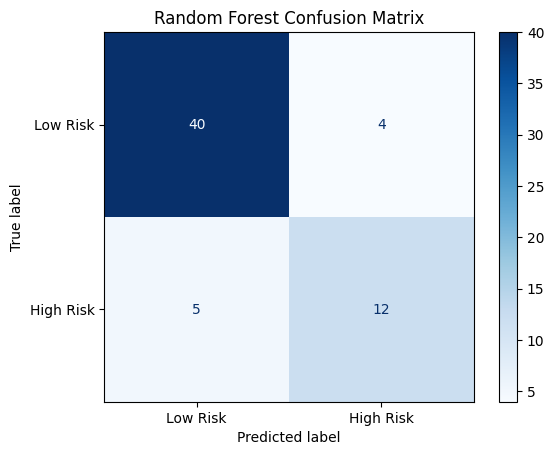

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_scaled, y_train)
log_preds = log_model.predict(X_test_scaled)


rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)

print("=== LOGISTIC REGRESSION REPORT ===")
print(classification_report(y_test, log_preds))

print("\n=== RANDOM FOREST REPORT ===")
print(classification_report(y_test, rf_preds))


print("\nGenerating Confusion Matrix Visual...")
cm = confusion_matrix(y_test, rf_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Risk', 'High Risk'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Random Forest Confusion Matrix")
plt.show()